In [2]:
# Install required libraries (run only once)
!pip install torch torchvision opencv-python matplotlib pandas scikit-learn


Defaulting to user installation because normal site-packages is not writeable


In [3]:
import torch
import torch.nn as nn
from torchvision import models, transforms   # 🔥 THIS LINE IMPORTANT
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import random

print("All libraries imported successfully!")


All libraries imported successfully!


In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# IMPORTANT: update path if needed
train_dataset = datasets.ImageFolder(
    root="dataset/train",   # change if your folder name is different
    transform=train_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = datasets.ImageFolder(
    root="dataset/test",   # change if your folder name is different
    transform=train_transform
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Training images:", len(test_dataset))

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Training images: 700
Training images: 700


In [5]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [6]:
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer3 and layer4
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

# Replace final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 7)

model = model.to(device)

print("Model ready with partial fine-tuning!")


Model ready with partial fine-tuning!


In [9]:
#  NEW OPTIMIZER: Higher learning rate for FASTER convergence
import torch.optim as optim

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001  # DOUBLED from 0.0005 for faster learning
)

criterion = nn.CrossEntropyLoss()

print(" Optimizer updated: lr=0.001 for FAST training!")

⚡ Optimizer updated: lr=0.001 for FAST training!


In [10]:
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (i+1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Step [{i+1}/{len(train_loader)}] "
                  f"Loss: {loss.item():.4f}")

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Average Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/50] Average Loss: 1.5501
Epoch [2/50] Average Loss: 1.2653
Epoch [3/50] Average Loss: 0.9930
Epoch [4/50] Average Loss: 0.8212
Epoch [5/50] Average Loss: 0.7236
Epoch [6/50] Average Loss: 0.6026
Epoch [7/50] Average Loss: 0.5294
Epoch [8/50] Average Loss: 0.5414
Epoch [9/50] Average Loss: 0.4299
Epoch [10/50] Average Loss: 0.2795
Epoch [11/50] Average Loss: 0.2308
Epoch [12/50] Average Loss: 0.2539
Epoch [13/50] Average Loss: 0.1966
Epoch [14/50] Average Loss: 0.1989
Epoch [15/50] Average Loss: 0.2100
Epoch [16/50] Average Loss: 0.2607
Epoch [17/50] Average Loss: 0.1612
Epoch [18/50] Average Loss: 0.1623
Epoch [19/50] Average Loss: 0.1011
Epoch [20/50] Average Loss: 0.1020
Epoch [21/50] Average Loss: 0.1411
Epoch [22/50] Average Loss: 0.0970
Epoch [23/50] Average Loss: 0.0872
Epoch [24/50] Average Loss: 0.0873
Epoch [25/50] Average Loss: 0.0862
Epoch [26/50] Average Loss: 0.0815
Epoch [27/50] Average Loss: 0.0678
Epoch [28/50] Average Loss: 0.0969
Epoch [29/50] Average Loss: 0

In [11]:
torch.save(model.state_dict(), "emotion_model.pth")
print("Model saved successfully!")


Model saved successfully!


In [12]:
correct = 0
total = 0

model.eval()  # set model to evaluation mode

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 41.14%


In [13]:
pip install pandas numpy scikit-learn nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
import numpy as np
import zipfile
import re
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [15]:
import os

for root, dirs, files in os.walk("dataset"):
    for file in files:
        print(file)

PublicTest_6385751.jpg
PublicTest_6510637.jpg
PublicTest_6998820.jpg
PublicTest_84366.jpg
PublicTest_84812303.jpg
PublicTest_84889722.jpg
PublicTest_85354228.jpg
PublicTest_85454471.jpg
PublicTest_85586711.jpg
PublicTest_85640402.jpg
PublicTest_8568840.jpg
PublicTest_8608284.jpg
PublicTest_86413860.jpg
PublicTest_86533062.jpg
PublicTest_8668068.jpg
PublicTest_86863879.jpg
PublicTest_87312658.jpg
PublicTest_87391496.jpg
PublicTest_87724897.jpg
PublicTest_87739948.jpg
PublicTest_87821224.jpg
PublicTest_87834425.jpg
PublicTest_8807439.jpg
PublicTest_88085937.jpg
PublicTest_88420742.jpg
PublicTest_88558122.jpg
PublicTest_88659438.jpg
PublicTest_89139321.jpg
PublicTest_89354196.jpg
PublicTest_89420020.jpg
PublicTest_89421273.jpg
PublicTest_89722367.jpg
PublicTest_89771874.jpg
PublicTest_89957354.jpg
PublicTest_90129237.jpg
PublicTest_90347378.jpg
PublicTest_90378794.jpg
PublicTest_90606955.jpg
PublicTest_90906370.jpg
PublicTest_91336201.jpg
PublicTest_91350708.jpg
PublicTest_9139860.jpg
Pub

In [16]:
import pandas as pd
import os

#  Dataset path
dataset_path = "musics"
dataframes = []

#  Artist → Genre mapping
artist_to_genre = {
    "Eminem": "Hardcore Hip-hop",
    "Drake": "Melodic Hip-hop",
    "CardiB": "Trap",
    "NickiMinaj": "Hip-hop",

    "BTS": "K-pop",
    "ArianaGrande": "Pop R&B",
    "DuaLipa": "Dance Pop",
    "JustinBieber": "Pop",
    "SelenaGomez": "Pop",
    "EdSheeran": "Acoustic",
    "LadyGaga": "Electropop",
    "Rihanna": "R&B",
    "CharliePuth": "Pop",

    "ColdPlay": "Alternative Rock",
    "Maroon5": "Pop Rock",

    "BillieEilish": "Dark Pop",
    "Khalid": "Soul R&B",

    "TaylorSwift": "Country Pop",
    "ArijitSingh": "Bollywood",
    "ShreyaGhoshal": "Classical",
    "NehaKakkar": "Bollywood Pop"
}

#  Read all CSV files (NO emotion folders now)
for file in os.listdir(dataset_path):

    if file.endswith(".csv") and "checkpoint" not in file:

        file_path = os.path.join(dataset_path, file)

        try:
            df_temp = pd.read_csv(file_path)

            #  Extract artist name
            artist = file.replace(".csv", "")

            #  Assign genre
            genre = artist_to_genre.get(artist, "Unknown")

            # Add columns
            df_temp["artist"] = artist
            df_temp["genre"] = genre

            dataframes.append(df_temp)

        except Exception as e:
            print(" Error reading:", file, e)

#  Combine
if len(dataframes) == 0:
    print("No CSV files found. Check folder path.")
else:
    df = pd.concat(dataframes, ignore_index=True)

    print(" Total rows:", len(df))
    print("\nSample Data:")
    print(df.head())

    print("\nGenre Distribution:")
    print(df['genre'].value_counts())

✅ Total rows: 5075

Sample Data:
          Artist                   Title            Album        Date  \
0  Ariana Grande          ​thank u, next    thank u, next  2018-11-03   
1  Ariana Grande                 7 rings    thank u, next  2019-01-18   
2  Ariana Grande         ​God is a woman        Sweetener  2018-07-13   
3  Ariana Grande            Side To Side  Dangerous Woman  2016-05-20   
4  Ariana Grande  ​​no tears left to cry        Sweetener  2018-04-20   

                                               Lyric    Year        artist  \
0  thought i'd end up with sean but he wasn't a m...  2018.0  ArianaGrande   
1  yeah breakfast at tiffany's and bottles of bub...  2019.0  ArianaGrande   
2  you you love it how i move you you love it how...  2018.0  ArianaGrande   
3  ariana grande  nicki minaj i've been here all ...  2016.0  ArianaGrande   
4  right now i'm in a state of mind i wanna be in...  2018.0  ArianaGrande   

     genre  Unnamed: 0  
0  Pop R&B         NaN  
1  Pop R&

In [17]:
print(df.columns)

Index(['Artist', 'Title', 'Album', 'Date', 'Lyric', 'Year', 'artist', 'genre',
       'Unnamed: 0'],
      dtype='str')


In [18]:
df.rename(columns={
    'Lyric': 'lyrics',
    'genre': 'genre',
}, inplace=True)

In [19]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_lyrics'] = df['lyrics'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lekha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
from sklearn.model_selection import train_test_split

X = df['clean_lyrics']
y = df['genre']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [22]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [23]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.4886699507389163


In [24]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

In [25]:
def recommend_songs(emotion, df, n=5):
    genres = emotion_to_genre.get(emotion, [])
    keywords = emotion_keywords.get(emotion, [])

    # Step 1: Filter by genre
    filtered = df[df['genre'].isin(genres)]

    # Step 2: Filter by lyrics keywords (NLP logic)
    if keywords:
        filtered = filtered[
            filtered['clean_lyrics'].str.contains('|'.join(keywords), na=False)
        ]

    # Step 3: If too few songs, fallback to genre only
    if len(filtered) < n:
        filtered = df[df['genre'].isin(genres)]

    # Step 4: Return songs
    recommendations = filtered.sample(n=min(n, len(filtered)))

    return recommendations[['Title', 'Artist', 'genre']]

In [26]:
emotion_to_genre = {
    "Happy": ["Pop", "R&B"],
    "Sad": ["Alternative", "Pop"],
    "Angry": ["Hip-hop", "Rock"],
    "Disgust": ["Hip-hop"],
    "Fear": ["Rock", "Pop"],
    "Neutral": ["Alternative", "R&B"],
    "Surprise": ["R&B", "Pop"]
}

In [27]:
emotion_keywords = {
    "Happy": ["love", "smile", "joy", "happy"],
    "Sad": ["cry", "alone", "pain", "tears"],
    "Angry": ["hate", "fight", "rage", "anger"],
    "Disgust": ["bad", "worst", "disgust"],
    "Excitement": ["party", "dance", "night", "fun"],
    "Calm": ["peace", "slow", "calm", "relax"],
    "Romantic": ["love", "heart", "kiss"]
}

In [28]:
emotion = "Fear"   # Try: Happy, Sad, Angry, Excitement, etc.

songs = recommend_songs(emotion, df)

for i, row in songs.iterrows():
    print(f" {row['Title']} — {row['Artist']} ({row['genre']})")

🎵 Out of Town Girl — Justin Bieber (Pop)
🎵 Pray — Justin Bieber (Pop)
🎵 In The Dark — Charlie Puth (Pop)
🎵 That Should Be Me (Remix) — Justin Bieber (Pop)
🎵 Vatican — Justin Bieber (Pop)


In [29]:
print(df.columns)

Index(['Artist', 'Title', 'Album', 'Date', 'lyrics', 'Year', 'artist', 'genre',
       'clean_lyrics'],
      dtype='str')


In [30]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable


In [31]:
import cv2
import numpy as np
from PIL import Image
import torch
from torchvision import models, transforms

# Load the trained emotion model
model = models.resnet18(weights=None)
num_features = model.fc.in_features
model.fc = torch.nn.Linear(num_features, 7)
model.load_state_dict(torch.load("emotion_model.pth"))
model = model.to(device)
model.eval()

# Define emotion labels
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

# Define preprocessing for the webcam frames
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✓ Emotion model loaded successfully!")
print("Emotion classes:", emotion_labels)

✓ Emotion model loaded successfully!
Emotion classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


In [32]:
import cv2
import torch
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

def capture_and_detect_emotion(duration=10, show_recommendations=True):
    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print(" Error: Could not access webcam!")
        return None

    print(f" Starting webcam capture for {duration} seconds...\n")

    fps = 10   # safer default (Jupyter issue fix)
    frame_count = 0
    max_frames = duration * fps

    detected_emotions = []
    emotion_counts = {emotion: 0 for emotion in emotion_labels}

    while frame_count < max_frames:
        ret, frame = cap.read()

        if not ret:
            print(" Failed to read frame")
            break

        frame = cv2.flip(frame, 1)

        # Convert for model
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(rgb_frame)

        # Prediction
        with torch.no_grad():
            image_tensor = transform(pil_image).unsqueeze(0).to(device)
            output = model(image_tensor)
            probabilities = torch.softmax(output, dim=1)

            predicted_idx = torch.argmax(output, dim=1).item()
            predicted_emotion = emotion_labels[predicted_idx]
            confidence = probabilities[0][predicted_idx].item()

        detected_emotions.append(predicted_emotion)
        emotion_counts[predicted_emotion] += 1

        # Display text on frame
        cv2.putText(frame, f"{predicted_emotion} ({confidence:.2f})",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

        #  Jupyter display (instead of cv2.imshow)
        clear_output(wait=True)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(f"Emotion: {predicted_emotion}")
        plt.axis('off')
        display(plt.gcf())
        plt.close()

        frame_count += 1

    cap.release()

    # Summary
    if len(detected_emotions) == 0:
        print(" No emotions detected")
        return None

    most_common_emotion = max(emotion_counts, key=emotion_counts.get)
    percentage = (emotion_counts[most_common_emotion] / len(detected_emotions)) * 100

    print("\n SUMMARY")
    print("="*40)
    for emotion in emotion_labels:
        count = emotion_counts[emotion]
        perc = (count / len(detected_emotions)) * 100
        print(f"{emotion:10}: {perc:.1f}% ({count})")

    print(f"\n Dominant Emotion: {most_common_emotion} ({percentage:.1f}%)")

    #  Recommendations
    if show_recommendations:
        print(f"\n Songs for {most_common_emotion}:\n")
        songs = recommend_songs(most_common_emotion, df, n=5)
        for _, row in songs.iterrows():
            print(f"♪ {row['Title']} — {row['Artist']} ({row['genre']})")

    return most_common_emotion, emotion_counts, detected_emotions

print(" Function ready!")

✅ Function ready!


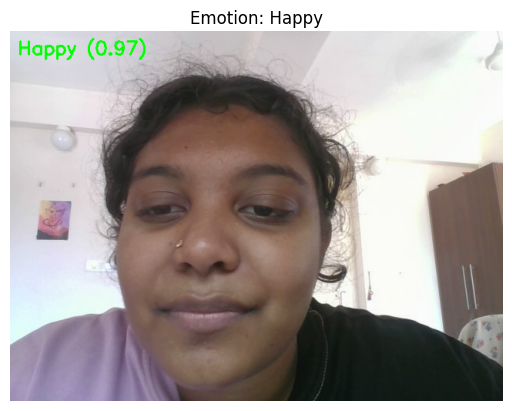


📊 SUMMARY
Angry     : 0.0% (0)
Disgust   : 0.0% (0)
Fear      : 24.3% (17)
Happy     : 55.7% (39)
Neutral   : 0.0% (0)
Sad       : 5.7% (4)
Surprise  : 14.3% (10)

🎯 Dominant Emotion: Happy (55.7%)

🎵 Songs for Happy:

♪ Pick Me — Justin Bieber (Pop)
♪ Been You — Justin Bieber (Pop)
♪ If It’s Lovin’ That You Want — Rihanna (R&B)
♪ Baby (Acoustic) — Justin Bieber (Pop)
♪ Nothing Like Us — Justin Bieber (Pop)


In [53]:
DURATION = 7
SHOW_MUSIC_RECOMMENDATIONS = True

emotion, counts, all_emotions = capture_and_detect_emotion(
    duration=DURATION,
    show_recommendations=SHOW_MUSIC_RECOMMENDATIONS
)

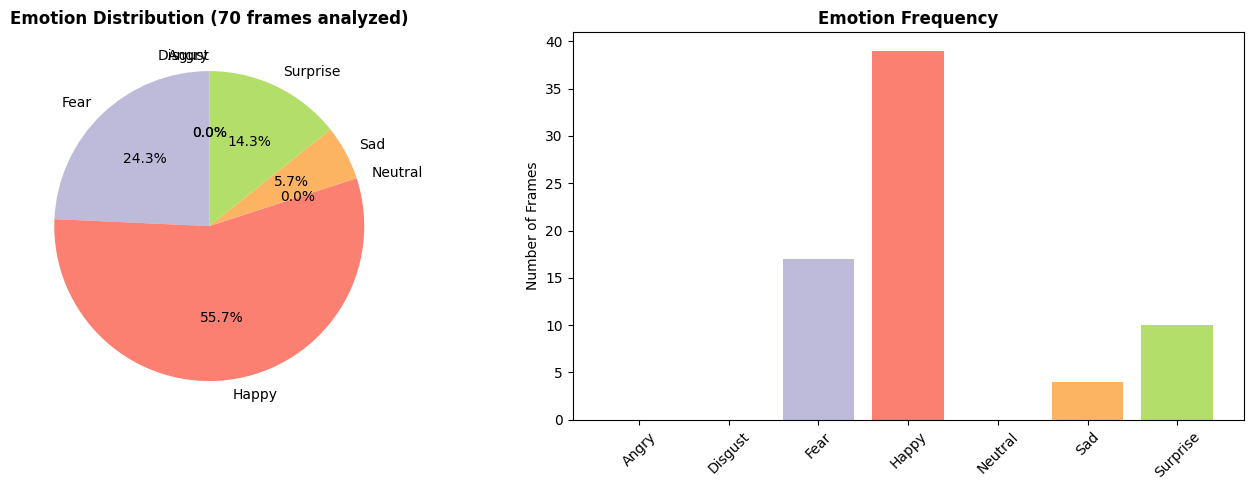


✅ Webcam session complete! Dominant emotion detected: Happy
Total frames processed: 70


In [54]:
import matplotlib.pyplot as plt

# Visualize emotion distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart of emotions
emotions_list = list(counts.keys())
counts_list = list(counts.values())
colors = plt.cm.Set3(range(len(emotions_list)))

axes[0].pie(counts_list, labels=emotions_list, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title(f'Emotion Distribution ({len(all_emotions)} frames analyzed)', fontsize=12, fontweight='bold')

# Bar chart
axes[1].bar(emotions_list, counts_list, color=colors)
axes[1].set_ylabel('Number of Frames')
axes[1].set_title('Emotion Frequency', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\n Webcam session complete! Dominant emotion detected: {emotion}")
print(f"Total frames processed: {len(all_emotions)}")